# Station calibration

This notebook uses only saved station inputs. Run data preparation first for a new station or period, then edit this one configuration cell.

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from cn3s import StationCalibrationWorkflow

In [13]:
station_code = "13870000"
frequency = "M"
data_root = Path("/data/CN3S")
warmup_steps = 10
train_ratio = 0.8
max_act = 0
objective = "PlainNSE"
optimizer_options = {"seed": 42, "maxiter": 100, "popsize": 5, "polish": False, "workers": -1, "disp": False}
run_label = "daily-reference"
polish_maxiter = 50
polish_maxfun = 500

In [14]:
workflow = StationCalibrationWorkflow.from_prepared(data_root)

In [15]:
workflow.preparation_report(station_code, frequency)

,value
station_code,13870000
frequency,M
start,2000-01-01
end,2026-08-01
rain_steps,320
observed_steps,317
paired_steps,317
upstream_area_km2,226439.336627
saved_in,/data/CN3S/stations/13870000


In [16]:
results = workflow.calibrate_station(
    station_code, frequency, warmup_steps=warmup_steps, train_ratio=train_ratio,
    max_act=max_act, objective=objective, optimizer_options=optimizer_options,
    label=run_label, progress=True, polish_maxiter=polish_maxiter,
    polish_maxfun=polish_maxfun,
)

Calibration: differential evolution


1 - Train objective: 3.6718 - [759.53, 38.62, 0.42, 0.02, 0.08, 0.15, 0.23]
2 - Train objective: 3.6718 - [759.53, 38.62, 0.42, 0.02, 0.08, 0.15, 0.23]
3 - Train objective: 3.6718 - [759.53, 38.62, 0.42, 0.02, 0.08, 0.15, 0.23]
4 - Train objective: 1.2265 - [230.82, 48.82, 0.4, 0.0, 0.57, 0.44, 0.31]
5 - Train objective: 0.4938 - [219.88, 37.36, 0.52, 0.0, 0.53, 0.44, 0.14]
6 - Train objective: 0.4938 - [219.88, 37.36, 0.52, 0.0, 0.53, 0.44, 0.14]
7 - Train objective: 0.4938 - [219.88, 37.36, 0.52, 0.0, 0.53, 0.44, 0.14]
8 - Train objective: 0.4938 - [219.88, 37.36, 0.52, 0.0, 0.53, 0.44, 0.14]
9 - Train objective: 0.4938 - [219.88, 37.36, 0.52, 0.0, 0.53, 0.44, 0.14]
10 - Train objective: 0.4938 - [219.88, 37.36, 0.52, 0.0, 0.53, 0.44, 0.14]
11 - Train objective: 0.4938 - [219.88, 37.36, 0.52, 0.0, 0.53, 0.44, 0.14]
12 - Train objective: 0.4938 - [219.88, 37.36, 0.52, 0.0, 0.53, 0.44, 0.14]
13 - Train objective: 0.4938 - [219.88, 37.36, 0.52, 0.0, 0.53, 0.44, 0.14]
14 - Train objectiv

In [17]:
workflow.calibration_settings(station_code, frequency)

,value
station_code,13870000
frequency,M
objective,PlainNSE
rain_period,"{'start': '2000-01-01', 'end': '2026-08-01'}"
train_ratio,0.8
warmup_steps,10
max_act,0
optimizer_options,"{'maxiter': 100, 'workers': -1, 'disp': False,..."
converged,True
split_date,2021-02-01


In [18]:
workflow.calibration_parameters(station_code, frequency)

,fitted value
name,Station 13870000
area,226439.336627
r0,50.090903
cn_i,10.078816
alfa,0.850894
beta,0.002015
k0,0.231393
k1,0.543238
k2,0.348138
act,0


In [19]:
workflow.calibration_quality(station_code, frequency)

,period,paired_steps,NSE
0,training,243,0.735395
1,held-out test,64,0.717097


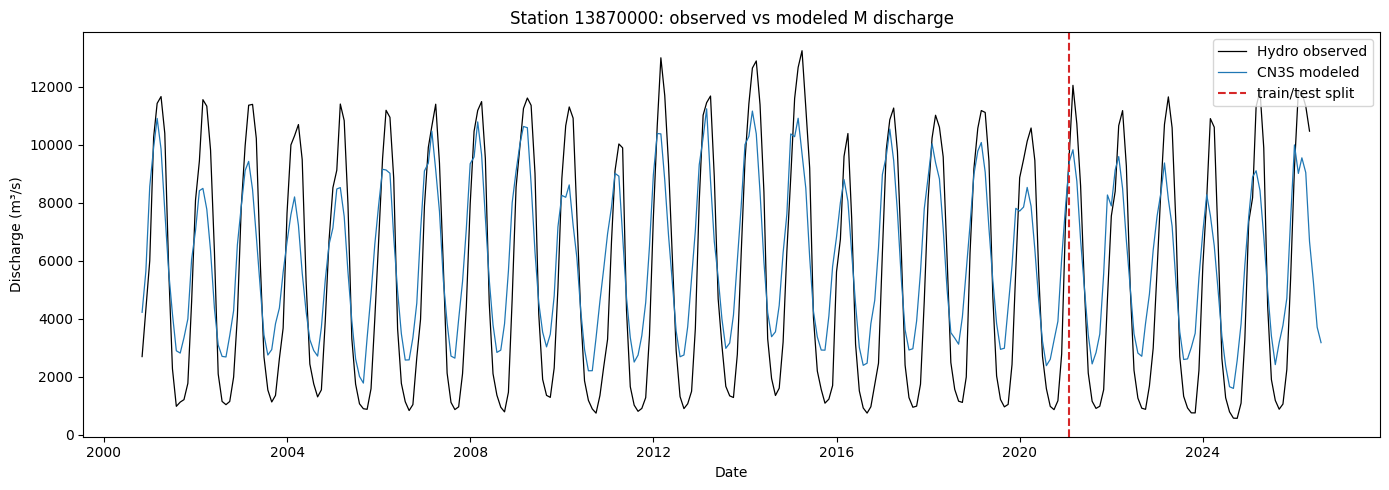

In [20]:
fig = workflow.calibration_figure(station_code, frequency)

Each call saves a distinct run and snapshots its inputs. Phase messages distinguish evolution, optional local refinement, final simulation, scoring and writes. Set `polish=False` for a quick fit; refinement budgets are separate from the DE budget. Use notebook 04 to evaluate and experiment without another calibration.